**Live Deployment Link:** https://YOUR-APP-NAME.streamlit.app  *(replace with your deployed link)*

---
# Heart Disease Prediction System

## Introduction

##### **Definition** A binary classification ML task that predicts whether a patient has heart disease (Yes) or not (No) from four clinical attributes.
##### **Application** Early screening support and learning how clinical factors relate to heart disease.

## Input and Output

### Inputs (4 attributes selected from the UCI Heart Disease dataset, Cleveland data)

| **Input Attribute** | **Original UCI Name** | **Possible Values** |
| --- | --- | --- |
| **Sex** | sex | Male, Female |
| **ChestPain** | cp | Typical Angina, Atypical Angina, Non-Anginal Pain, Asymptomatic |
| **RestECG** | restecg | Normal, ST-T Abnormality, LV Hypertrophy |
| **ExerciseAngina** | exang | Yes, No |

### Output (Prediction)

| **Output Attribute** | **Possible Values** |
| --- | --- |
| **HeartDisease** | Yes, No |

The original UCI target `num` has values 0 to 4. As is standard for this dataset, 0 means *No* (absence) and 1-4 mean *Yes* (presence).

## Developer & System Information

| | |
| --- | --- |
| **Developer Name** | *(add your name)* |
| **Registration No.** | *(add yours)* |
| **Course** | AIC354 Machine Learning Fundamentals, COMSATS University Islamabad, Lahore Campus |
| **Instructor** | Dr. Rao Muhammad Adeel Nawab |
| **Program Name** | heart_disease_project |
| **IDE** | Jupyter Notebook |
| **Programming Language** | Python 3 |
| **Libraries** | NumPy, Pandas, Pickle, scikit-learn, PrettyTable, Matplotlib, Seaborn |
| **Dataset** | UCI Heart Disease (Cleveland, 303 instances): https://archive.ics.uci.edu/dataset/45/heart+disease |


## Table of Content
- Step 1: Import Libraries
- Step 2: Load Sample Data
- Step 3: Understand and Pre-process Sample Data
- Step 4: Feature Extraction
- Step 5: Label Encoding the Sample Data
- Step 6: Execute the Training Phase
- Step 7: Execute the Testing Phase
- Step 8: Execute the Application Phase
- Step 9: Execute the Feedback Phase
- Step 10: Deploy the Model as a Public Web App


### Step 1: Import Libraries

In [1]:
"""
Purpose of this code:
----------------------
Imports the libraries needed to load the data, label encode it, train and
evaluate a Support Vector Classifier, save the model, and show the results.
"""

# NumPy: numerical arrays (used to flatten columns for the label encoders)
import numpy as np

# Pandas: DataFrames, reading and writing CSV files
import pandas as pd

# Pickle: saving and loading the trained model to/from a file
import pickle

# train_test_split: divides the data into training and testing sets
from sklearn.model_selection import train_test_split

# LabelEncoder: converts text categories into numeric codes
from sklearn.preprocessing import LabelEncoder

# Support Vector Machine module (we use its SVC classifier)
from sklearn import svm

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PrettyTable: prints the final prediction in a clean table
from prettytable import PrettyTable

# Matplotlib and Seaborn: plot the confusion matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Sample Data

`sample-data.csv` was created from the UCI file `processed.cleveland.data` (included in `heart_disease.zip`). Only 4 of the 13 input attributes were kept (`sex`, `cp`, `restecg`, `exang`), their numeric codes were replaced with readable text labels (using the codebook in `heart-disease.names`), and the target `num` was converted to Yes (1-4) / No (0). The conversion script is in Step 2.1 below, so the process is reproducible.

#### Step 2.1: (Optional) Re-create sample-data.csv from the raw UCI file

In [2]:
"""
Purpose of this section:
-------------------------
Re-creates 'sample-data.csv' from the raw UCI file 'processed.cleveland.data'.
This is optional: if the raw file is not in the folder, the existing
'sample-data.csv' is used. Steps performed:
1. Name the 14 columns of the UCI file (the file has no header row).
2. Keep only 4 input attributes: sex, cp, restecg, exang.
3. Replace numeric codes with readable text (codebook: heart-disease.names).
4. Convert the target 'num' (0-4) to Yes/No (0 = No, 1-4 = Yes).
"""
import os

# Only rebuild the CSV if the raw UCI file is available
if os.path.exists("processed.cleveland.data"):

    # Column names of the UCI Cleveland file, in file order
    cols = "age sex cp trestbps chol fbs restecg thalach exang oldpeak slope ca thal num".split()

    # Read the raw file; '?' marks missing values in this dataset
    raw = pd.read_csv("processed.cleveland.data", header=None, names=cols, na_values="?")

    # Build the new DataFrame with only the 4 chosen inputs + the output
    pd.DataFrame({
        "Sex": raw.sex.map({1: "Male", 0: "Female"}),
        "ChestPain": raw.cp.map({1: "Typical Angina", 2: "Atypical Angina",
                                 3: "Non-Anginal Pain", 4: "Asymptomatic"}),
        "RestECG": raw.restecg.map({0: "Normal", 1: "ST-T Abnormality", 2: "LV Hypertrophy"}),
        "ExerciseAngina": raw.exang.map({1: "Yes", 0: "No"}),
        "HeartDisease": (raw.num > 0).map({True: "Yes", False: "No"}),
    }).to_csv("sample-data.csv", index=False)

    print("sample-data.csv re-created from processed.cleveland.data")
else:
    print("processed.cleveland.data not found, using the existing sample-data.csv")

sample-data.csv re-created from processed.cleveland.data


#### Step 2.2: Load the data

In [3]:
"""
Purpose of this section:
-------------------------
Loads the sample data from the CSV file into a pandas DataFrame and
displays the first rows so the raw data can be inspected.
"""

# Read the CSV file ('sample-data.csv' must be in the working directory)
sample_data = pd.read_csv("sample-data.csv")

print("\n\nSample Data (first 15 rows):")
print("============================\n")

# Show the first 15 rows only (the full dataset has 303 rows)
print(sample_data.head(15))



Sample Data (first 15 rows):

       Sex         ChestPain         RestECG ExerciseAngina HeartDisease
0     Male    Typical Angina  LV Hypertrophy             No           No
1     Male      Asymptomatic  LV Hypertrophy            Yes          Yes
2     Male      Asymptomatic  LV Hypertrophy            Yes          Yes
3     Male  Non-Anginal Pain          Normal             No           No
4   Female   Atypical Angina  LV Hypertrophy             No           No
5     Male   Atypical Angina          Normal             No           No
6   Female      Asymptomatic  LV Hypertrophy             No          Yes
7   Female      Asymptomatic          Normal            Yes           No
8     Male      Asymptomatic  LV Hypertrophy             No          Yes
9     Male      Asymptomatic  LV Hypertrophy            Yes          Yes
10    Male      Asymptomatic          Normal             No           No
11  Female   Atypical Angina  LV Hypertrophy             No           No
12    Male  Non-Ang

### Step 3: Understand and Pre-process Sample Data

#### Step 3.1: Understand Sample Data

In [4]:
"""
Purpose of this section:
-------------------------
Helps us understand the dataset by showing:
1. The attribute (column) names.
2. The number of instances (rows).
3. Missing values per column.
4. How many examples each class and each category has.
"""

# 1. Attribute names
print("\n\nAttributes in Sample Data:")
print("==========================\n")
print(sample_data.columns)

# 2. Number of instances
print("\n\nNumber of Instances in Sample Data:", sample_data["Sex"].count())
print("========================================\n")

# 3. Missing values (should all be 0 for the 4 attributes we selected)
print("Missing values per column:")
print(sample_data.isnull().sum())

# 4a. Class balance of the output attribute
print("\nClass distribution of the output:")
print(sample_data["HeartDisease"].value_counts())

# 4b. Category counts for every input attribute
for col in ["Sex", "ChestPain", "RestECG", "ExerciseAngina"]:
    print(f"\n{col}:")
    print(sample_data[col].value_counts())



Attributes in Sample Data:

Index(['Sex', 'ChestPain', 'RestECG', 'ExerciseAngina', 'HeartDisease'], dtype='str')


Number of Instances in Sample Data: 303

Missing values per column:
Sex               0
ChestPain         0
RestECG           0
ExerciseAngina    0
HeartDisease      0
dtype: int64

Class distribution of the output:
HeartDisease
No     164
Yes    139
Name: count, dtype: int64

Sex:
Sex
Male      206
Female     97
Name: count, dtype: int64

ChestPain:
ChestPain
Asymptomatic        144
Non-Anginal Pain     86
Atypical Angina      50
Typical Angina       23
Name: count, dtype: int64

RestECG:
RestECG
Normal              151
LV Hypertrophy      148
ST-T Abnormality      4
Name: count, dtype: int64

ExerciseAngina:
ExerciseAngina
No     204
Yes     99
Name: count, dtype: int64


#### Step 3.2: Pre-process Sample Data
- The 4 chosen attributes contain **no missing values** (the UCI Cleveland file only has missing values in `ca` and `thal`, which we did not select).
- Text labels were already assigned in Step 2.
- No further preprocessing needs to be performed.

#### Step 4: Feature Extraction
- The 4 features are already extracted (selected from the UCI dataset).
- No Feature Extraction needs to be Performed

### Step 5: Label Encoding the Sample Data (Input and Output is converted in Numeric Representation)

#### Step 5.1: Train the Label Encoder

In [5]:
"""
Purpose of this section:
-------------------------
Sets up and trains one LabelEncoder per attribute. Label Encoding converts
text values (e.g. 'Male', 'Asymptomatic') into numbers the model can use.

Steps:
1. Define every possible value (category) of each attribute.
2. Create a LabelEncoder for each attribute.
3. Train (fit) each encoder on its categories.
"""

# Step 1: all possible values of each attribute
sex = pd.DataFrame({"Sex": ["Male", "Female"]})
chestpain = pd.DataFrame({"ChestPain": ["Typical Angina", "Atypical Angina",
                                        "Non-Anginal Pain", "Asymptomatic"]})
restecg = pd.DataFrame({"RestECG": ["Normal", "ST-T Abnormality", "LV Hypertrophy"]})
exerciseangina = pd.DataFrame({"ExerciseAngina": ["Yes", "No"]})
heartdisease = pd.DataFrame({"HeartDisease": ["Yes", "No"]})

# Step 2: one encoder per attribute
sex_label_encoder = LabelEncoder()
chestpain_label_encoder = LabelEncoder()
restecg_label_encoder = LabelEncoder()
exerciseangina_label_encoder = LabelEncoder()
heartdisease_label_encoder = LabelEncoder()

# Step 3: fit each encoder (np.ravel flattens the column into a 1D array)
sex_label_encoder.fit(np.ravel(sex))
chestpain_label_encoder.fit(np.ravel(chestpain))
restecg_label_encoder.fit(np.ravel(restecg))
exerciseangina_label_encoder.fit(np.ravel(exerciseangina))
heartdisease_label_encoder.fit(np.ravel(heartdisease))

# Print the learned codes (LabelEncoder numbers categories in alphabetical order)
for name, enc in [("Sex", sex_label_encoder), ("ChestPain", chestpain_label_encoder),
                  ("RestECG", restecg_label_encoder),
                  ("ExerciseAngina", exerciseangina_label_encoder),
                  ("HeartDisease", heartdisease_label_encoder)]:
    print(name, "->", {c: int(i) for i, c in enumerate(enc.classes_)})

Sex -> {'Female': 0, 'Male': 1}
ChestPain -> {'Asymptomatic': 0, 'Atypical Angina': 1, 'Non-Anginal Pain': 2, 'Typical Angina': 3}
RestECG -> {'LV Hypertrophy': 0, 'Normal': 1, 'ST-T Abnormality': 2}
ExerciseAngina -> {'No': 0, 'Yes': 1}
HeartDisease -> {'No': 0, 'Yes': 1}


#### Step 5.2: Label Encode the Output

In [6]:
"""
Purpose of this section:
-------------------------
Label encodes the output attribute 'HeartDisease' (Yes/No -> 1/0).
"""

# Keep copies: one to hold the encoded output, one as the untouched original
sample_data_encoded_output = sample_data.copy()
original_sample_data = sample_data.copy()

print("\n\nHeartDisease Attribute After Label Encoding:")
print("============================================\n")

# Transform the output column using the trained encoder
sample_data["encoded_heartdisease"] = heartdisease_label_encoder.transform(sample_data["HeartDisease"])

# Show original text values next to their numeric codes
print(sample_data[["HeartDisease", "encoded_heartdisease"]].head(10))

# Put the encoded output into the output-encoded copy
sample_data_encoded_output[["Sex", "ChestPain", "RestECG", "ExerciseAngina", "HeartDisease"]] = \
    sample_data[["Sex", "ChestPain", "RestECG", "ExerciseAngina", "encoded_heartdisease"]]

# Save to CSV for later use
sample_data_encoded_output.to_csv("sample-data-encoded-output.csv", index=False, header=True)
print("\nSaved: sample-data-encoded-output.csv")



HeartDisease Attribute After Label Encoding:

  HeartDisease  encoded_heartdisease
0           No                     0
1          Yes                     1
2          Yes                     1
3           No                     0
4           No                     0
5           No                     0
6          Yes                     1
7           No                     0
8          Yes                     1
9          Yes                     1

Saved: sample-data-encoded-output.csv


#### Step 5.3: Label Encode the Input

In [7]:
"""
Purpose of this section:
-------------------------
Label encodes the four input attributes (Sex, ChestPain, RestECG,
ExerciseAngina) so every column in the dataset is numeric.
"""

# Copy of the dataset whose input columns will be replaced by numbers
sample_data_encoded = sample_data_encoded_output.copy()

# Encode each input attribute with its own trained encoder
sample_data_encoded_output["encoded_sex"] = sex_label_encoder.transform(sample_data_encoded_output["Sex"])
sample_data_encoded_output["encoded_chestpain"] = chestpain_label_encoder.transform(sample_data_encoded_output["ChestPain"])
sample_data_encoded_output["encoded_restecg"] = restecg_label_encoder.transform(sample_data_encoded_output["RestECG"])
sample_data_encoded_output["encoded_exerciseangina"] = exerciseangina_label_encoder.transform(sample_data_encoded_output["ExerciseAngina"])

# Replace the text columns with the encoded ones (output is already encoded)
sample_data_encoded[["Sex", "ChestPain", "RestECG", "ExerciseAngina", "HeartDisease"]] = \
    sample_data_encoded_output[["encoded_sex", "encoded_chestpain", "encoded_restecg",
                                "encoded_exerciseangina", "HeartDisease"]]

print("\n\nSample Data after Label Encoding:")
print("=================================\n")
print(sample_data_encoded.head(15))

# Save the fully encoded dataset
sample_data_encoded.to_csv("sample-data-encoded.csv", index=False, header=True)



Sample Data after Label Encoding:

    Sex  ChestPain  RestECG  ExerciseAngina  HeartDisease
0     1          3        0               0             0
1     1          0        0               1             1
2     1          0        0               1             1
3     1          2        1               0             0
4     0          1        0               0             0
5     1          1        1               0             0
6     0          0        0               0             1
7     0          0        1               1             0
8     1          0        0               0             1
9     1          0        0               1             1
10    1          0        1               0             0
11    0          1        0               0             0
12    1          2        0               1             1
13    1          1        1               0             0
14    1          2        1               0             0


### Step 6: Execute the Training Phase

#### Step 6.1: Splitting Sample Data into Training Data and Testing Data
80% training / 20% testing. Unlike the Titanic notebook (`shuffle=False`), this split **shuffles** the rows and **stratifies** on the output, so both sets keep the same Yes/No proportion. `random_state=0` keeps the split reproducible.

In [8]:
"""
Purpose of this section:
-------------------------
Splits the data into Training Data (teaches the model) and Testing Data
(checks the model on unseen examples).
"""

# 80% training / 20% testing
# random_state=0 -> same split on every run (reproducible)
# shuffle=True   -> rows are mixed before splitting (the UCI file is not randomly ordered)
# stratify=...   -> training and testing sets keep the same Yes/No proportion
training_data_encoded, testing_data_encoded = train_test_split(
    sample_data_encoded,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    stratify=sample_data_encoded["HeartDisease"]
)

# Save both sets to CSV files
training_data_encoded.to_csv("training-data-encoded.csv", index=False, header=True)
testing_data_encoded.to_csv("testing-data-encoded.csv", index=False, header=True)

print("Training Data shape:", training_data_encoded.shape)
print("Testing Data shape:", testing_data_encoded.shape)

Training Data shape: (242, 5)
Testing Data shape: (61, 5)


### Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data

In [9]:
"""
Purpose of this section:
-------------------------
Separates the input vectors (features) from the output labels
in the training data.
"""

# All columns except the last one = input features
input_vector_train = training_data_encoded.iloc[:, :-1]

# The last column = output label (HeartDisease)
output_label_train = training_data_encoded.iloc[:, -1]

print("Input vectors (train) shape:", input_vector_train.shape)
print("Output labels (train) shape:", output_label_train.shape)

Input vectors (train) shape: (242, 4)
Output labels (train) shape: (242,)


### Step 6.3: Train the Support Vector Classifier

In [10]:
"""
Purpose of this section:
-------------------------
Trains a Support Vector Classifier (SVC). The SVC finds the best boundary
that separates the two classes (heart disease vs. no heart disease).
"""

print("\n\nTraining the Support Vector Classifier on Training Data")
print("========================================================\n")

# gamma='auto' sets the kernel coefficient automatically; random_state=0 for reproducibility
svc_model = svm.SVC(gamma="auto", random_state=0)

# Train the model on the training features and labels
svc_model.fit(input_vector_train, np.ravel(output_label_train))

# Show the trained model and its parameters
print(svc_model)



Training the Support Vector Classifier on Training Data

SVC(gamma='auto', random_state=0)


### Step 6.4: Save the Trained Model

In [11]:
"""
Purpose of this section:
-------------------------
Saves the trained model to disk so it can be reused (and deployed)
without retraining.
"""

# 'wb' = write in binary mode
pickle.dump(svc_model, open("heart_svc_trained_model.pkl", "wb"))
print("Saved: heart_svc_trained_model.pkl")

Saved: heart_svc_trained_model.pkl


### Step 7: Execute the Testing Phase

#### Step 7.1: Splitting Input Vectors and Outputs/Labels of Testing Data

In [12]:
"""
Purpose of this section:
-------------------------
Separates the input vectors and the output labels in the testing data.
"""

input_vector_test = testing_data_encoded.iloc[:, :-1]   # features
output_label_test = testing_data_encoded.iloc[:, -1]    # true labels

print("Input vectors (test) shape:", input_vector_test.shape)
print("Output labels (test) shape:", output_label_test.shape)

Input vectors (test) shape: (61, 4)
Output labels (test) shape: (61,)


### Step 7.2: Load the Saved Model

In [13]:
"""
Purpose of this section:
-------------------------
Loads the previously saved model from disk into memory.
"""

# 'rb' = read in binary mode
model = pickle.load(open("heart_svc_trained_model.pkl", "rb"))
print("Model loaded from heart_svc_trained_model.pkl")

Model loaded from heart_svc_trained_model.pkl


### Step 7.3: Evaluate the Machine Learning Model

#### Step 7.3.1: Make Predictions with the Trained Model on Testing Data

In [14]:
"""
Purpose of this section:
-------------------------
Uses the trained model to predict the output for the testing data.
"""

# Predict a label (0/1) for every row of the test inputs
model_predictions = model.predict(input_vector_test)

# Hide a harmless pandas warning when adding a column below
pd.options.mode.chained_assignment = None

# Add the predictions next to the true labels so they can be compared
testing_data_encoded["Predictions"] = model_predictions
testing_data_encoded.to_csv("model-predictions.csv", index=False, header=True)

model_predictions = testing_data_encoded
print("\n\nPredictions Returned by heart_svc_trained_model:")
print("================================================\n")
print(model_predictions.head(15))



Predictions Returned by heart_svc_trained_model:

     Sex  ChestPain  RestECG  ExerciseAngina  HeartDisease  Predictions
125    0          1        0               0             0            0
83     1          2        0               1             1            0
53     1          1        0               0             0            0
45     1          2        0               0             1            0
248    1          0        1               0             1            0
211    1          3        1               1             1            0
36     1          0        0               1             1            1
106    1          0        1               1             1            1
120    1          0        0               1             1            1
31     1          0        1               1             1            1
156    1          0        1               1             1            1
157    1          0        0               0             1            1
148    1    

### Step 7.4: Calculate the Accuracy Score

In [15]:
"""
Purpose of this section:
-------------------------
Calculates the accuracy: the fraction of test examples predicted correctly.
"""

# Compare true labels with predicted labels
model_accuracy_score = accuracy_score(model_predictions["HeartDisease"],
                                      model_predictions["Predictions"])

print("\n\nAccuracy Score:")
print("===============\n")
print(round(model_accuracy_score, 2))



Accuracy Score:

0.82


### Step 7.5: Detailed Evaluation Metrics (Precision, Recall, F1, Confusion Matrix)


Classification Report:

                      precision    recall  f1-score   support

No Heart Disease (0)       0.76      0.97      0.85        33
   Heart Disease (1)       0.95      0.64      0.77        28

            accuracy                           0.82        61
           macro avg       0.85      0.81      0.81        61
        weighted avg       0.85      0.82      0.81        61


Confusion Matrix:

             Predicted: No  Predicted: Yes
Actual: No              32               1
Actual: Yes             10              18


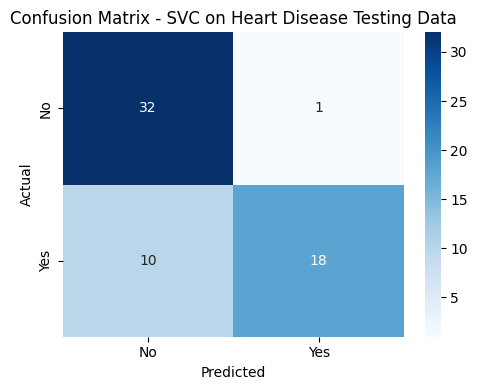

In [16]:
"""
Purpose of this section:
-------------------------
Accuracy alone can be misleading, so we also report:
- Precision: of the patients predicted as having heart disease, how many really have it?
- Recall: of the patients who really have heart disease, how many did the model find?
- F1-score: balance (harmonic mean) of precision and recall.
- Confusion Matrix: correct vs. wrong predictions for each class.
"""

# Precision, recall and F1 for each class
print("\nClassification Report:")
print("=======================\n")
print(classification_report(
    model_predictions["HeartDisease"],
    model_predictions["Predictions"],
    target_names=["No Heart Disease (0)", "Heart Disease (1)"]
))

# Confusion matrix as a labelled table
conf_matrix = confusion_matrix(model_predictions["HeartDisease"], model_predictions["Predictions"])
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: No", "Actual: Yes"],
    columns=["Predicted: No", "Predicted: Yes"]
)
print("\nConfusion Matrix:")
print("==================\n")
print(conf_matrix_df)

# Confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVC on Heart Disease Testing Data")
plt.tight_layout()
plt.show()

### Step 8: Execute the Application Phase

#### Step 8.1: Take Input from User

A demo patient is pre-filled so the notebook runs top-to-bottom. To enter your own values interactively, replace the four lines with:
```python
sex_input = input("Sex (Male, Female): ").strip()
chestpain_input = input("ChestPain (Typical Angina, Atypical Angina, Non-Anginal Pain, Asymptomatic): ").strip()
restecg_input = input("RestECG (Normal, ST-T Abnormality, LV Hypertrophy): ").strip()
exerciseangina_input = input("ExerciseAngina (Yes, No): ").strip()
```

In [17]:
"""
Purpose of this section:
-------------------------
Takes the four input values of a new patient. A demo patient is pre-filled
so the notebook runs top-to-bottom without typing. Edit the values below
(or use the input() lines from the markdown cell above) to try your own.
Allowed values:
  Sex            : Male, Female
  ChestPain      : Typical Angina, Atypical Angina, Non-Anginal Pain, Asymptomatic
  RestECG        : Normal, ST-T Abnormality, LV Hypertrophy
  ExerciseAngina : Yes, No
"""

# Demo patient
sex_input = "Male"
chestpain_input = "Asymptomatic"
restecg_input = "Normal"
exerciseangina_input = "Yes"

print(f"Sex: {sex_input}, ChestPain: {chestpain_input}, RestECG: {restecg_input}, ExerciseAngina: {exerciseangina_input}")

Sex: Male, ChestPain: Asymptomatic, RestECG: Normal, ExerciseAngina: Yes


### Step 8.2: Convert User Input into Feature Vector (Exactly Same as Feature Vectors of Sample Data)

In [18]:
"""
Purpose of this section:
-------------------------
Puts the user's text input into a one-row DataFrame with the same columns
as the sample data (the model expects the same structure).
"""

user_input = pd.DataFrame({
    "Sex": [sex_input],
    "ChestPain": [chestpain_input],
    "RestECG": [restecg_input],
    "ExerciseAngina": [exerciseangina_input]
})

print("\n\nUser Input Feature Vector:")
print("==========================\n")
print(user_input)



User Input Feature Vector:



    Sex     ChestPain RestECG ExerciseAngina
0  Male  Asymptomatic  Normal            Yes


### Step 8.3: Label Encoding of Feature Vector (Exactly Same as Label Encoded Feature Vectors of Sample Data)

In [19]:
"""
Purpose of this section:
-------------------------
Converts the user's text input into numbers using the SAME trained
encoders that were used for the training data (so codes match).
"""

# Work on a copy so the original user input stays readable
unseen_data_features = user_input.copy()

unseen_data_features["Sex"] = sex_label_encoder.transform(user_input["Sex"])
unseen_data_features["ChestPain"] = chestpain_label_encoder.transform(user_input["ChestPain"])
unseen_data_features["RestECG"] = restecg_label_encoder.transform(user_input["RestECG"])
unseen_data_features["ExerciseAngina"] = exerciseangina_label_encoder.transform(user_input["ExerciseAngina"])

print("\n\nUser Input Encoded Feature Vector:")
print("==================================\n")
print(unseen_data_features)



User Input Encoded Feature Vector:



   Sex  ChestPain  RestECG  ExerciseAngina
0    1          0        1               1


### Step 8.4: Load the Saved Model

In [20]:
"""
Purpose of this section:
-------------------------
Loads the saved model again for the Application Phase.
"""

model = pickle.load(open("heart_svc_trained_model.pkl", "rb"))

### Step 8.5: Model Prediction

#### Step 8.5.1: Apply Model on the Label Encoded Feature Vector of unseen instance and return Prediction to the User

In [21]:
"""
Purpose of this section:
-------------------------
Predicts whether the new patient is likely to have heart disease and
shows the result to the user.
"""

# Model returns an array, e.g. [1]; [0] picks the single value
predicted_disease = model.predict(unseen_data_features)

# Convert the numeric prediction back to a readable message
if predicted_disease[0] == 1:
    prediction = "HEART DISEASE LIKELY"
else:
    prediction = "NO HEART DISEASE LIKELY"

# Display the prediction in a table
pretty_table = PrettyTable()
pretty_table.add_column("       ** Prediction **       ", [prediction])
print(pretty_table)

+--------------------------------+
|        ** Prediction **        |
+--------------------------------+
|      HEART DISEASE LIKELY      |
+--------------------------------+


### Step 9: Execute the Feedback Phase

#### Step 9.1: Collect Feedback from Users and Domain Experts on Performance of the Model Deployed in the Real World

In [22]:
"""
Purpose of this section:
-------------------------
Step 9.1: Example feedback from domain experts and testers who reviewed
the model's predictions on real-world-style cases.
"""

example_feedback = pd.DataFrame({
    "Reviewer": ["Domain Expert (Cardiology)", "Student Tester", "Domain Expert (Cardiology)"],
    "Case": [
        "Male, Asymptomatic chest pain, Exercise angina = Yes -> predicted HEART DISEASE LIKELY",
        "Female, Atypical Angina, Normal ECG, No exercise angina -> predicted NO HEART DISEASE",
        "Using only 4 attributes ignores age, cholesterol, blood pressure, max heart rate",
    ],
    "Feedback": [
        "Consistent with clinical knowledge: asymptomatic presentation with exercise-induced angina is a strong risk pattern in this dataset.",
        "Prediction looks reasonable.",
        "Important risk factors are missing; the model should not be used as a diagnostic tool.",
    ],
})
print(example_feedback.to_string(index=False))

                  Reviewer                                                                                   Case                                                                                                                             Feedback
Domain Expert (Cardiology) Male, Asymptomatic chest pain, Exercise angina = Yes -> predicted HEART DISEASE LIKELY Consistent with clinical knowledge: asymptomatic presentation with exercise-induced angina is a strong risk pattern in this dataset.
            Student Tester  Female, Atypical Angina, Normal ECG, No exercise angina -> predicted NO HEART DISEASE                                                                                                         Prediction looks reasonable.
Domain Expert (Cardiology)       Using only 4 attributes ignores age, cholesterol, blood pressure, max heart rate                                               Important risk factors are missing; the model should not be used as a diagnostic tool.


#### Step 9.2: Make a List of Potential Improvements

In [23]:
"""
Purpose of this section:
-------------------------
Step 9.2: Improvements identified from the feedback above.
"""

improvements = [
    "Add numeric attributes such as Age, Max Heart Rate (thalach), ST depression (oldpeak) and Cholesterol",
    "Use cross-validation instead of a single 80/20 split for a more reliable accuracy estimate",
    "Combine the Hungarian, Switzerland and VA datasets for more training data",
    "Compare other models (Logistic Regression, Random Forest, Gradient Boosting)",
]

# Print as a numbered list
for i, item in enumerate(improvements, 1):
    print(f"{i}. {item}")

1. Add numeric attributes such as Age, Max Heart Rate (thalach), ST depression (oldpeak) and Cholesterol
2. Use cross-validation instead of a single 80/20 split for a more reliable accuracy estimate
3. Combine the Hungarian, Switzerland and VA datasets for more training data
4. Compare other models (Logistic Regression, Random Forest, Gradient Boosting)


#### Step 9.3: Improve the Model Based on Feedback

In [24]:
"""
Purpose of this section:
-------------------------
Step 9.3: In a real deployment the next version would retrain with the
improvements above, re-run Steps 6-7, and replace the deployed model only
if performance improves.
"""

print("Next version: add Age, thalach and oldpeak, use cross-validation, then re-run Steps 6-7 and replace heart_svc_trained_model.pkl only if performance improves.")

Next version: add Age, thalach and oldpeak, use cross-validation, then re-run Steps 6-7 and replace heart_svc_trained_model.pkl only if performance improves.


## Step 10: Deploy the Model as a Public Web App

The model is deployed with **Streamlit Community Cloud** (same method as the instructor's Titanic demo).

1. Create a public GitHub repository and upload `app.py`, `requirements.txt`, `runtime.txt` and `heart_svc_trained_model.pkl`.
2. Sign in at https://share.streamlit.io with GitHub, click **Create app**, choose the repo, branch `main`, main file `app.py`, and click **Deploy**.
3. If the build fails with a missing package, set **Settings -> General -> Python version** to 3.11.
4. Paste the live link into the first cell at the top of this notebook.

## Conclusion
A Support Vector Classifier trained on four clinical attributes (Sex, ChestPain, RestECG, ExerciseAngina) from the UCI Cleveland Heart Disease data predicts the presence of heart disease with about 82% accuracy on a held-out 20% test set (Step 7.4). Chest pain type and exercise-induced angina carry most of the signal. Because only four attributes are used, the model is an educational demo and not a diagnostic tool.